In [135]:
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt

In [136]:
import pickle

df = pickle.load(open('../Phase1/phase1_output.pickle', 'rb'))
print(df.shape)

(2777817, 37)


## Define columns

In [137]:
float_cols = ['loan_amnt', 'funded_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 
              'open_acc', 'pub_rec', 'fico_range_low', 'fico_range_high', 
              'revol_bal', 'total_pymnt', 'recoveries', 'inq_last_6mths',
              'pub_rec_bankruptcies', 'total_acc', 'mths_since_last_delinq']

perc_cols = ['int_rate', 'revol_util']

date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d']

cat_cols = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 
            'verification_status', 'loan_status', 'purpose', 'term','is_default']


# Features for modeling — exclude target and EDA-only columns
discrete_features = list(set(cat_cols) - set(['loan_status']))
continuous_features = float_cols + perc_cols

print("Discrete features:", discrete_features)
print("Continuous features:", continuous_features)

Discrete features: ['home_ownership', 'emp_length', 'purpose', 'verification_status', 'sub_grade', 'is_default', 'grade', 'term']
Continuous features: ['loan_amnt', 'funded_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'fico_range_low', 'fico_range_high', 'revol_bal', 'total_pymnt', 'recoveries', 'inq_last_6mths', 'pub_rec_bankruptcies', 'total_acc', 'mths_since_last_delinq', 'int_rate', 'revol_util']


In [138]:
print(df[float_cols].dtypes.unique())
print(df[perc_cols].dtypes.unique())
print(df[date_cols].dtypes.unique())
print(df[cat_cols].dtypes.unique())

[dtype('float64')]
[dtype('float64')]
[dtype('<M8[ns]') dtype('O')]
[dtype('O') dtype('int64')]


In [139]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce')

## Calculate returns for each loan

In [140]:
ret_cols = ["ret_PESS", "ret_OPT", "ret_INTa", "ret_INTb"]

In [141]:
# Calculate the loan length in months
df['loan_length'] = (df['last_pymnt_d'] - df['issue_d']).dt.days / 30.4375

# Handle any potential NaN values that could arise from the coercion
df['loan_length'] = df['loan_length'].fillna(0).astype(float)

# Remove rows where loan_length is 0
n_rows = len(df)
df = df[df['loan_length'] != 0]

print("Removed " + str(n_rows - len(df)) + " rows")

Removed 15699 rows


### M1-Pessimistic Method

In [142]:
# Calculate the return using a simple annualized profit margin
# Pessimistic definition (Handout 6a.) (M1)

df['term_num'] = df.term.str.extract('(\d+)',expand=False).astype(int) # length of loan in months

df['ret_PESS'] = (df['total_pymnt'] - df['funded_amnt']) / df['funded_amnt'] * (12 / df['term_num'])

### M2-Optimistic Method

In [143]:
# Assuming that if a loan gives a positive return, we can
# immediately find a similar loan to invest in; if the loan
# takes a loss, we use M1-pessimistic to compute the return

# Calculate the optimistic return
df['ret_OPT'] = np.where(df['total_pymnt'] > df['funded_amnt'],
                                 (df['total_pymnt'] - df['funded_amnt']) / df['funded_amnt'] * (12 / df['loan_length']),
                                 df['ret_PESS'])

# If the optimistic return is less than 0, default to the pessimistic return
df.loc[df['ret_OPT'] < 0, 'ret_OPT'] = df['ret_PESS']


### Method 3

In [144]:
def ret_method_3_vectorized(T, i):
    actual_installment = (df['total_pymnt'] - df['recoveries']) / df['loan_length']
    cash_by_end_of_loan = actual_installment * ((1 + i) ** df['loan_length'] - 1) / i
    cash_by_end_of_loan += df['recoveries']
    remaining_months = T - df['loan_length']
    final_return = cash_by_end_of_loan * (1 + i) ** remaining_months
    ret_val = (final_return - df['funded_amnt']) / df['funded_amnt'] * (12 / T)
    return ret_val

In [145]:
# Apply the vectorized function without using apply()
df['ret_INTa'] = ret_method_3_vectorized(60, 0.023)
df['ret_INTb'] = ret_method_3_vectorized(60, 0.04)

In [146]:
df[ret_cols].astype(float).describe()

,ret_PESS,ret_OPT,ret_INTa,ret_INTb
count,2.762118e+06,2.762118e+06,2.762118e+06,2.762118e+06
mean,-9.137745e-02,-7.094602e-02,2.254681e-01,7.947145e-01
std,1.173069e-01,1.436726e-01,2.427091e-01,5.730906e-01
min,-3.333333e-01,-3.333333e-01,-2.000000e-01,-2.000000e-01
25%,-1.814192e-01,-1.814192e-01,9.095175e-03,3.119442e-01
50%,-1.009133e-01,-1.009133e-01,1.893877e-01,6.876827e-01
75%,2.391471e-02,6.700221e-02,4.779800e-01,1.282428e+00
max,1.929856e-01,2.452595e+00,7.597834e-01,2.268091e+00


M1 has a mean of -9.13% which means that on average an investor will expect to lose money. Same goes for M2, where a borrower will lose money -7.09%. This number is slightly higher because it accounts for the fact that default risks should not be accounted over the entire loan period. M3 has positive returns of 22.5% and 79.47%, mainly because of reinvestment. 

### Visualize the variables

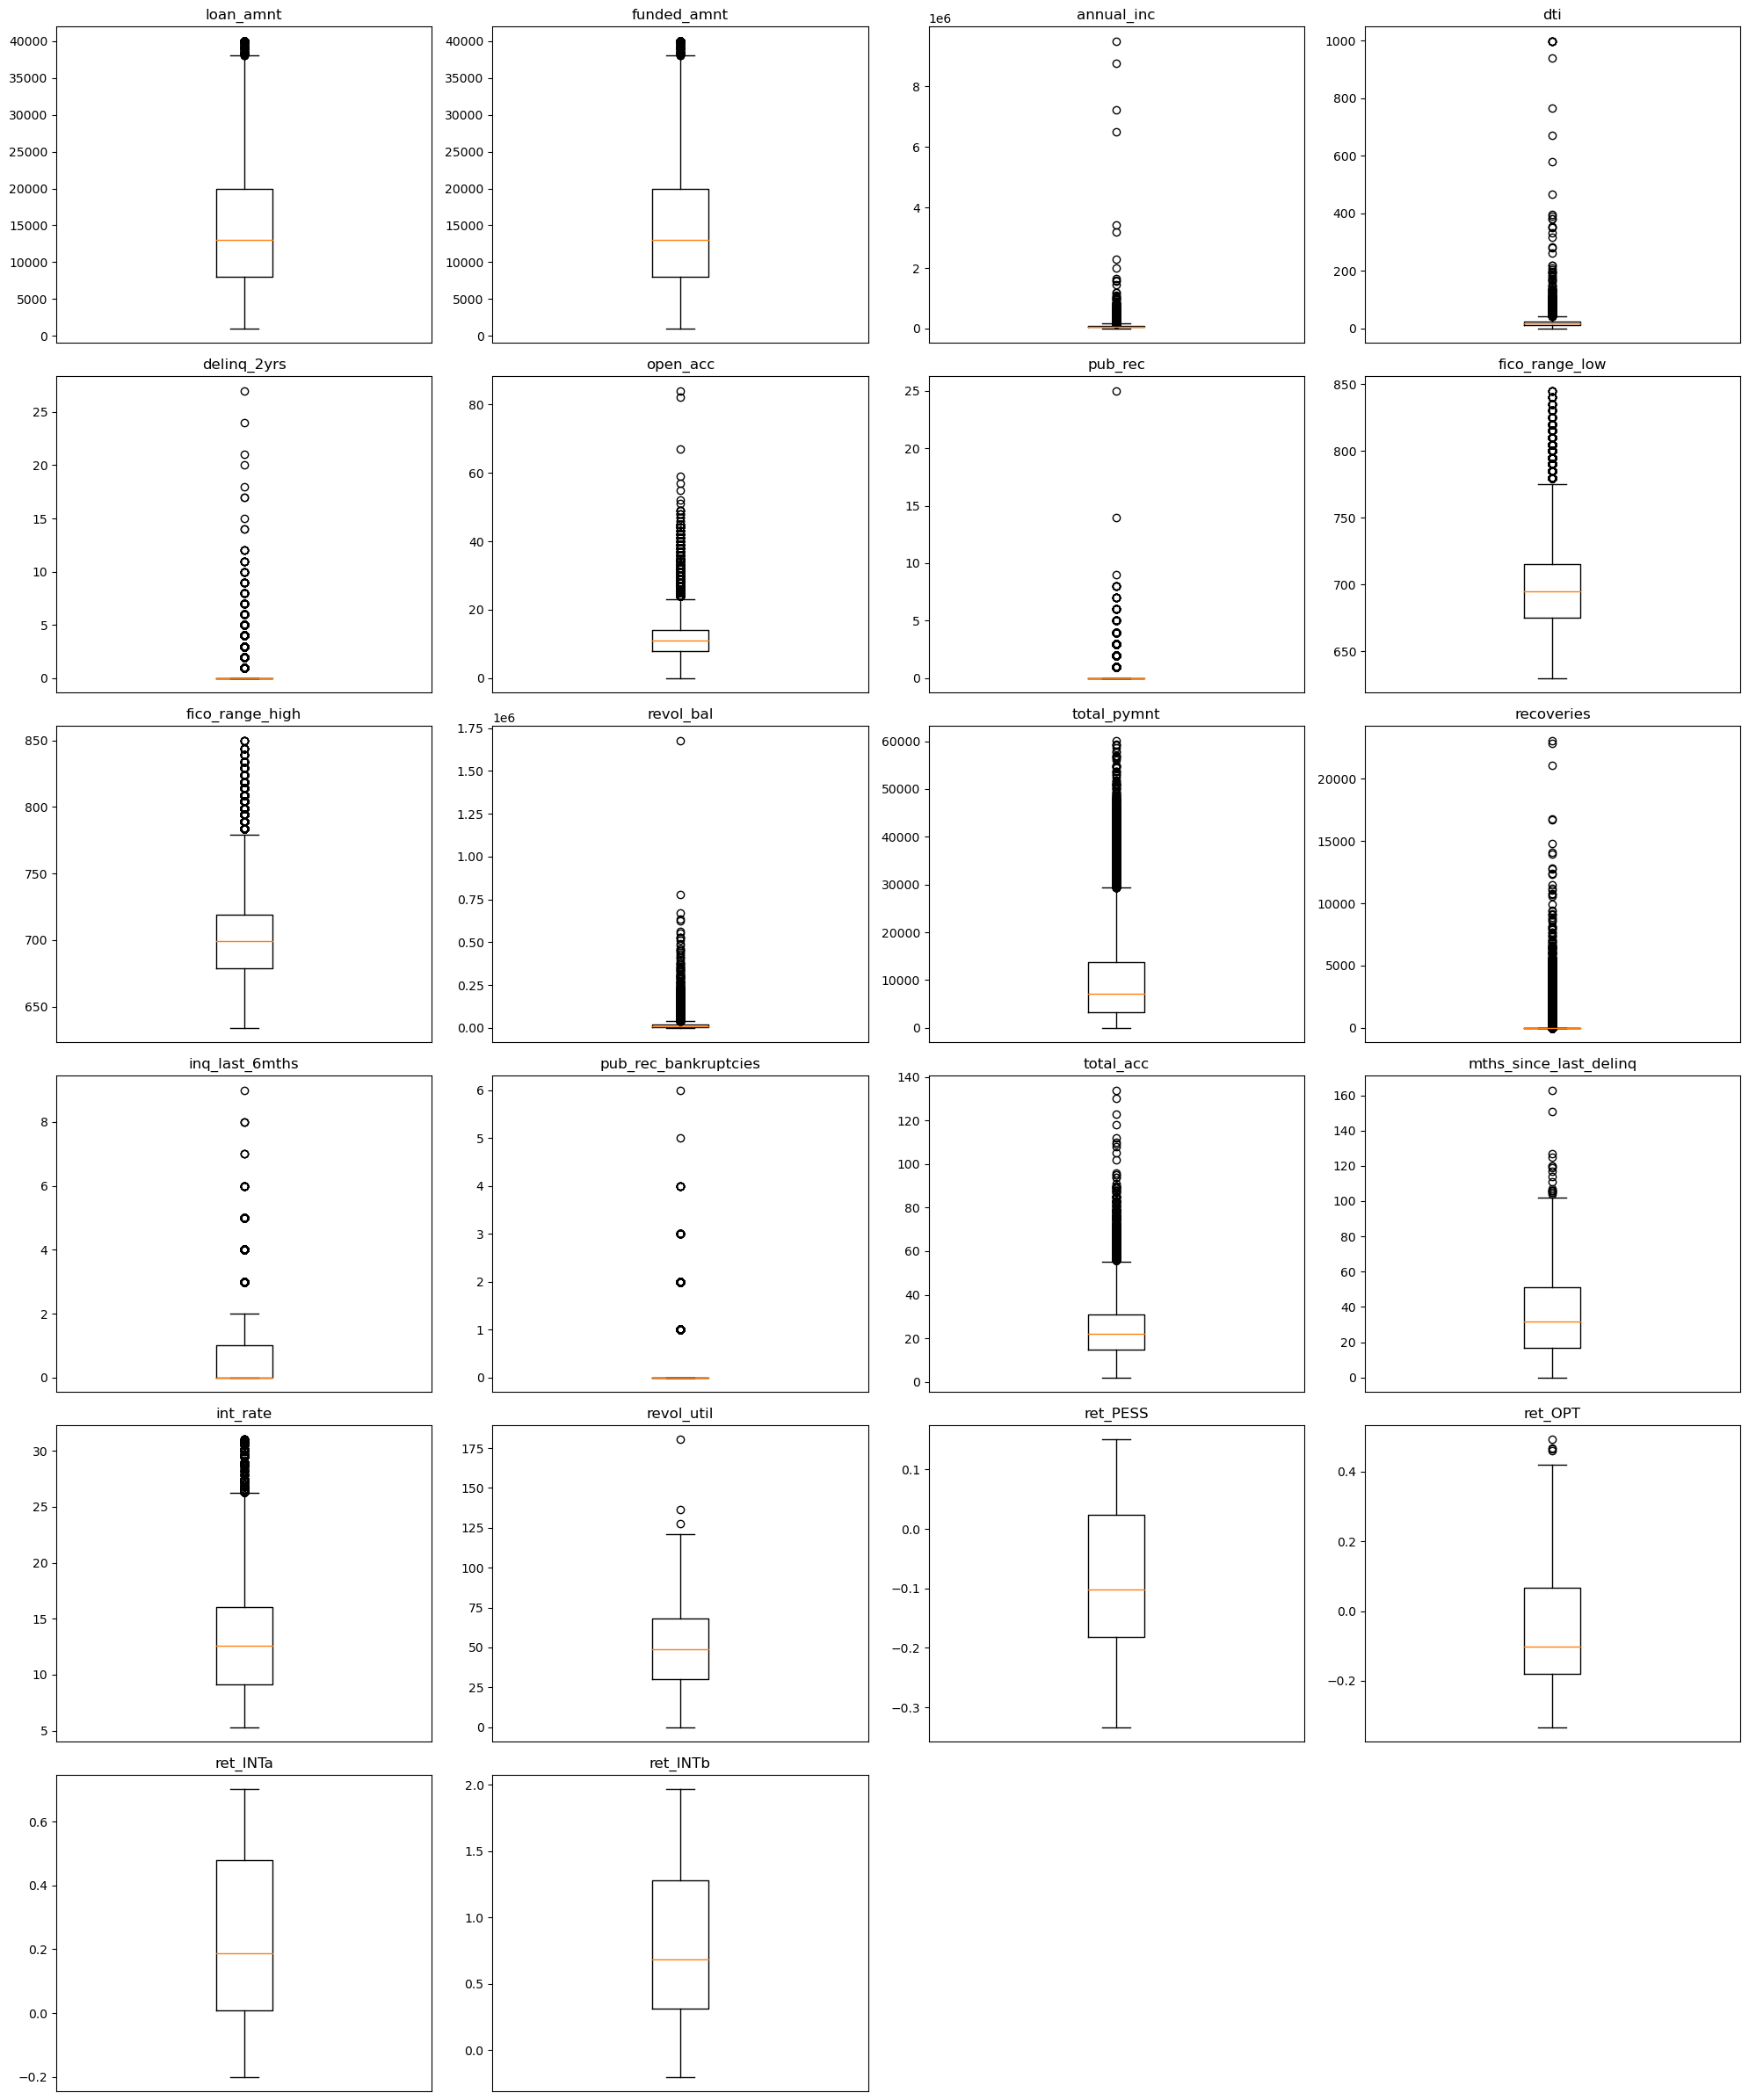

In [147]:
cols_to_viz = float_cols + perc_cols + ret_cols
n_cols = 4
n_rows = (len(cols_to_viz) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

# Sample 50K rows to keep plots readable
sample = df.sample(50000, random_state=42)

for i, col in enumerate(cols_to_viz):
    axes[i].boxplot(sample[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xticks([])

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [148]:
upper = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(upper=upper)

upper = df['revol_bal'].quantile(0.99)
df['revol_bal'] = df['revol_bal'].clip(upper=upper)

In [149]:
print(len(df[df['dti']>100])*100/len(df))

0.15734302444718148


In [150]:
# dti > 100 is most probably a data entry error
n_rows = len(df)
df = df[df['dti'] <= 100]
print(f"Removed {n_rows - len(df):,} rows with dti > 100")

Removed 7,184 rows with dti > 100


In [151]:
len(df)

2754934

In [152]:
def visualize_cat_columns():
    '''
    Lists the distinct values for categorical columns
    '''

    # Categorical columns
    for i in cat_cols:
        print(f"Column: {i}")  # print field name
        print(f"Number of distinct values: {df[i].nunique()}")  # print number of distinct values

        # for each distinct value print the number of occurrences
        print(df[i].value_counts())

        print("")
        print("")

In [153]:
# Visualize categorical features
visualize_cat_columns()

Column: grade
Number of distinct values: 7
grade
B    808732
C    765690
A    594584
D    395004
E    137603
F     41381
G     11940
Name: count, dtype: int64


Column: sub_grade
Number of distinct values: 35
sub_grade
B4    175913
C1    171369
B5    170018
B2    154420
C2    154332
B3    154294
B1    154087
C3    151790
C4    146974
A4    143448
C5    141225
A5    140714
A1    120474
D2    101590
D1     96970
A3     96110
A2     93838
D3     77982
D4     63881
D5     54581
E1     34558
E2     30038
E3     26962
E5     23101
E4     22944
F1     13285
F2      9214
F3      7717
F4      6054
F5      5111
G1      4031
G2      2650
G3      2065
G4      1669
G5      1525
Name: count, dtype: int64


Column: emp_length
Number of distinct values: 11
emp_length
10+ years    897080
< 1 year     252325
2 years      246792
3 years      219234
1 year       182587
5 years      171419
4 years      166189
6 years      123452
7 years      109915
8 years      107298
9 years       91291
Name: count, dtype

In [154]:
def visualize_date_columns():
    '''
    This function visualizes a timeline density for dates
    '''
    
    # Date columns
    for i in date_cols:
        df[df[i].isnull() == False][i].apply(lambda x : str(x.year) +
                                                "-" + str(x.month)).value_counts(ascending = True).plot()
        plt.title(i + " (" + str(df[i].isnull().sum()) + " null values)")
        plt.show()

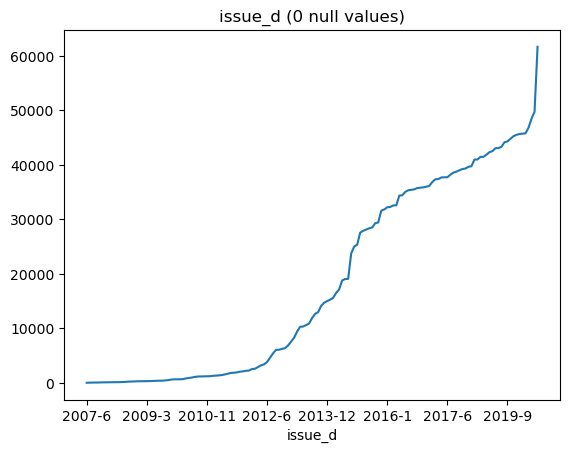

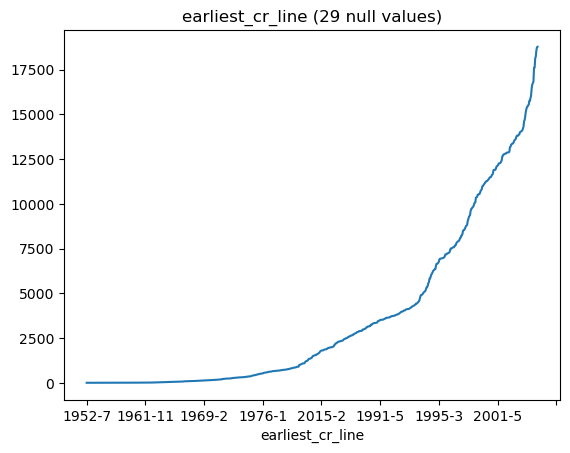

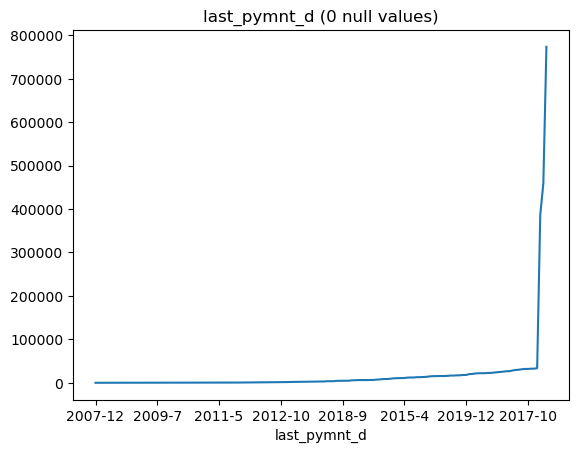

In [155]:
# Visualize date columns
visualize_date_columns()

### Remove Nulls & Outliers

In [156]:
# Remove outliers from loan_length only using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

n_rows = len(df)
df = remove_outliers(df, 'loan_length')
print(f"After loan_length outlier removal: {len(df):,} rows (removed {n_rows - len(df):,})")

After loan_length outlier removal: 2,728,853 rows (removed 26,081)


In [159]:
df.loan_status.value_counts()

loan_status
Current                                                1541437
Fully Paid                                              888430
Charged Off                                             233769
Late (31-120 days)                                       33416
In Grace Period                                          19322
Late (16-30 days)                                         8914
Does not meet the credit policy. Status:Fully Paid        1892
Default                                                    934
Does not meet the credit policy. Status:Charged Off        739
Name: count, dtype: int64

In [158]:
len(df[df['loan_status'] != 'Current'])

1187416

In [160]:
# Remove Current loans — outcome unknown
n_rows = len(df)
df = df[df['loan_status'] != 'Current']
print(f"After removing Current loans: {len(df):,} rows (removed {n_rows - len(df):,})")

After removing Current loans: 1,187,416 rows (removed 1,541,437)


In [161]:
df_check = df[df['loan_status'] != 'Current']
df_check = df_check[df_check['issue_d'] >= pd.to_datetime('2010-01-01')]
print(df_check[required_cols].isnull().sum().sort_values(ascending=False))

mths_since_last_delinq    604512
revol_util                   879
inq_last_6mths                 1
loan_amnt                      0
total_pymnt                    0
int_rate                       0
total_acc                      0
pub_rec_bankruptcies           0
recoveries                     0
revol_bal                      0
funded_amnt                    0
fico_range_high                0
fico_range_low                 0
pub_rec                        0
open_acc                       0
delinq_2yrs                    0
dti                            0
annual_inc                     0
grade                          0
dtype: int64


In [162]:
# mths_since_last_delinq — missing means never delinquent
# Impute with 999 as sentinel value
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)

# revol_util — small number of nulls, impute with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# inq_last_6mths — single null, impute with 0
df['inq_last_6mths'] = df['inq_last_6mths'].fillna(0)

# Now drop nulls on required columns
n_rows = len(df)
df = df.dropna(subset=required_cols)
print(f"After dropping nulls: {len(df):,} rows (removed {n_rows - len(df):,})")

After dropping nulls: 1,186,061 rows (removed 1,355)


In [163]:
print(df.shape)
print(df['loan_status'].value_counts())

(1186061, 43)
loan_status
Fully Paid                                             887856
Charged Off                                            233652
Late (31-120 days)                                      33416
In Grace Period                                         19322
Late (16-30 days)                                        8914
Does not meet the credit policy. Status:Fully Paid       1441
Default                                                   934
Does not meet the credit policy. Status:Charged Off       526
Name: count, dtype: int64


### Note on Current Loans

We remove all Current loans from the modeling dataset. While some may be 
near completion, their return calculations are incomplete we only observe 
payments up to the data snapshot date, not the full loan term. Including them 
would introduce systematic bias in our return estimates.

This means our model is trained on completed loans only (Fully Paid, Charged Off, 
Default, Late). This is standard practice for credit risk modeling on snapshot data.

### Heatmap

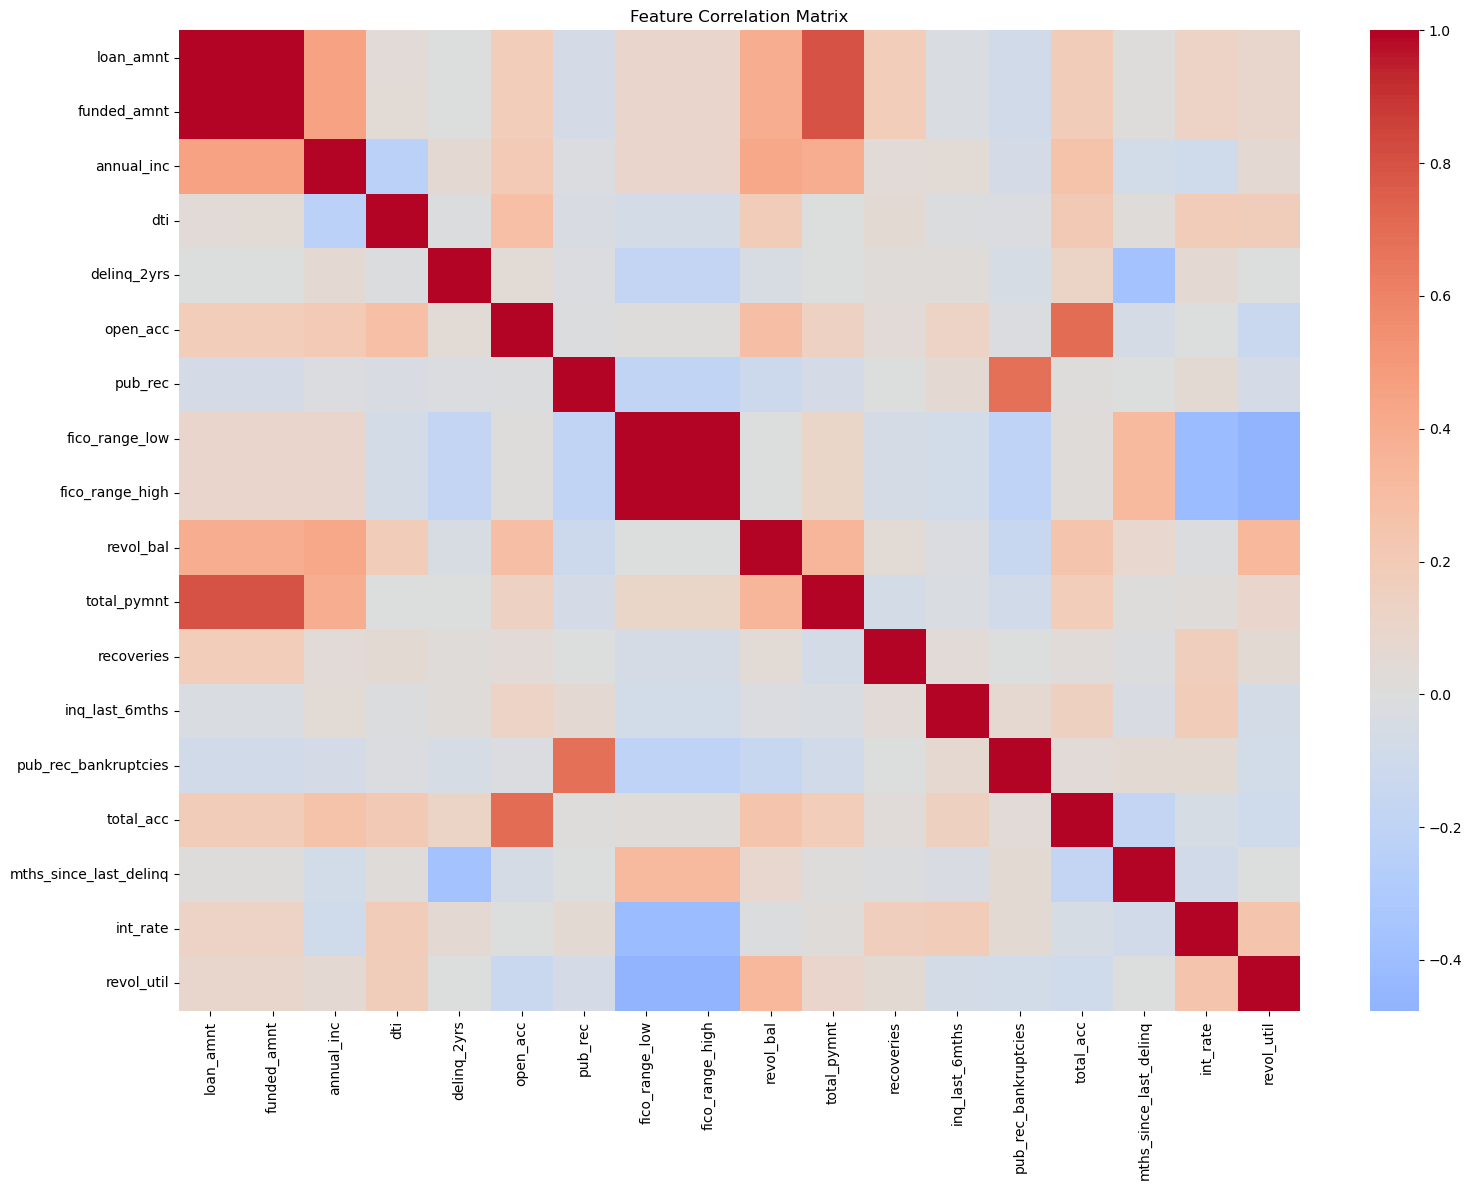

In [164]:
import seaborn as sns

numeric_cols = df[continuous_features].select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

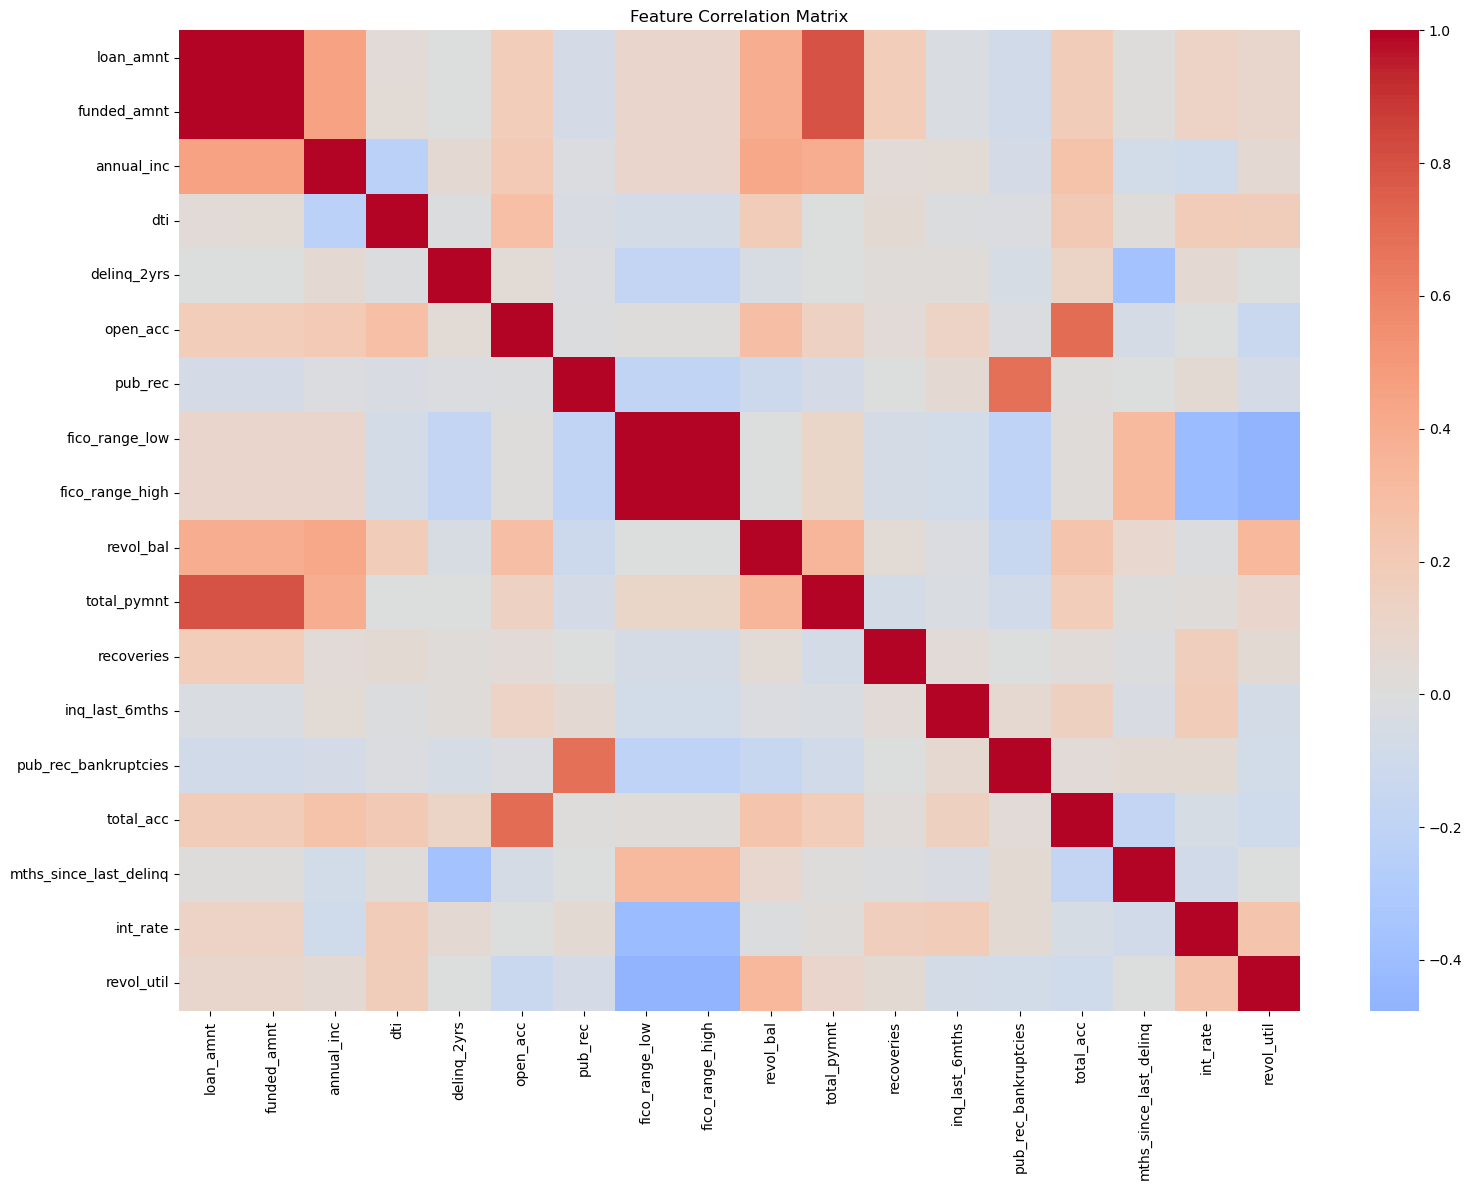

Top 20 most correlated feature pairs:
fico_range_high       fico_range_low          1.000000
fico_range_low        fico_range_high         1.000000
loan_amnt             funded_amnt             0.999634
funded_amnt           loan_amnt               0.999634
                      total_pymnt             0.799533
total_pymnt           funded_amnt             0.799533
loan_amnt             total_pymnt             0.799313
total_pymnt           loan_amnt               0.799313
open_acc              total_acc               0.697909
total_acc             open_acc                0.697909
pub_rec               pub_rec_bankruptcies    0.681166
pub_rec_bankruptcies  pub_rec                 0.681166
revol_util            fico_range_low          0.476356
fico_range_low        revol_util              0.476356
fico_range_high       revol_util              0.476354
revol_util            fico_range_high         0.476354
annual_inc            loan_amnt               0.454365
loan_amnt             annua

In [165]:
# Plot heatmap without numbers - too many columns
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print top correlated pairs separately
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlations
corr_pairs = corr_pairs.abs().sort_values(ascending=False)
print("Top 20 most correlated feature pairs:")
print(corr_pairs.head(20))

In [167]:
# Drop redundant features identified from correlation analysis
cols_to_drop = ['fico_range_high', 'funded_amnt']
df = df.drop(columns=cols_to_drop)

# Update continuous_features list
continuous_features = [c for c in continuous_features if c not in cols_to_drop]

print(f"Remaining shape: {df.shape}")
print(f"Continuous features: {continuous_features}")

Remaining shape: (1186061, 41)
Continuous features: ['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'fico_range_low', 'revol_bal', 'total_pymnt', 'recoveries', 'inq_last_6mths', 'pub_rec_bankruptcies', 'total_acc', 'mths_since_last_delinq', 'int_rate', 'revol_util']


In [176]:
import pickle
# Remove the "total_pymnt" and "recoveries" from the list of continuous features
continuous_features = [feature for feature in continuous_features if feature not in ('total_pymnt', 'recoveries')]
# save the prepared data
pickle_file = "../Phase2/clean_data.pickle" 
pickle.dump( [df, discrete_features, continuous_features, ret_cols], open(pickle_file, "wb") )

### Final Data Exploration

In [171]:
# Find the percentage of loans by grade
perc_by_grade = (df.grade.value_counts() * 100 / len(df)).sort_index()

# Find the default rate by grade
default_by_grade = df.groupby("grade").apply(lambda x: (x.loan_status != "Fully Paid").sum() * 100 / len(x))

# Find the average interest rate by grade
int_rate_by_grade = df.groupby("grade")['int_rate'].mean()

# Calculate the average return for each grade (using the given methods)
ret_by_grade_OPT = df.groupby("grade")['ret_OPT'].mean()
ret_by_grade_PESS = df.groupby("grade")['ret_PESS'].mean()
ret_by_grade_INTa = df.groupby("grade")['ret_INTa'].mean()
ret_by_grade_INTb = df.groupby("grade")['ret_INTb'].mean()

# Create a DataFrame to combine the results
combined = pd.DataFrame(perc_by_grade)
combined.columns = ['% of loans']
combined['% Default'] = default_by_grade
combined['avg. intrst'] = int_rate_by_grade
combined['M 1'] = ret_by_grade_PESS
combined['M 2'] = ret_by_grade_OPT
combined['M 3 (1.4%)'] = ret_by_grade_INTa
combined['M 3 (2%)'] = ret_by_grade_INTb

# Show the combined DataFrame
combined.index.name = 'Grade'
combined.reset_index(inplace=True)
combined

/var/folders/2b/mx4d8bfx64b0_mwy0_qmj1sh0000gn/T/ipykernel_36023/2208663328.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  default_by_grade = df.groupby("grade").apply(lambda x: (x.loan_status != "Fully Paid").sum() * 100 / len(x))


,Grade,% of loans,% Default,avg. intrst,M 1,M 2,M 3 (1.4%),M 3 (2%)
0,A,17.933395,9.215283,7.228668,0.006500,0.033695,0.445380,1.317198
1,B,28.318780,17.862140,10.880392,0.002761,0.040911,0.433009,1.283308
2,C,27.820576,28.417821,14.212410,-0.010366,0.039853,0.409443,1.236620
3,D,15.984760,36.923556,18.091637,-0.018923,0.041760,0.388318,1.189040
4,E,6.979574,44.326061,21.346548,-0.022547,0.047532,0.373983,1.153866
5,F,2.320201,50.572332,24.922305,-0.026280,0.051585,0.357773,1.116635
6,G,0.642716,55.424374,27.459843,-0.039465,0.047013,0.333296,1.072629


In [172]:
# Grade distribution
perc_by_grade = (df['grade'].value_counts() * 100 / len(df)).sort_index()
print("% of loans by grade:")
print(perc_by_grade)

# Default rate by grade
default_by_grade = df.groupby('grade')['is_default'].mean() * 100
print("\nDefault rate by grade:")
print(default_by_grade)

# Average interest rate by grade
int_by_grade = df.groupby('grade')['int_rate'].mean()
print("\nAverage interest rate by grade:")
print(int_by_grade)

# Average return by grade for all four methods
for col in ret_cols:
    print(f"\nAverage {col} by grade:")
    print(df.groupby('grade')[col].mean())

% of loans by grade:
grade
A    17.933395
B    28.318780
C    27.820576
D    15.984760
E     6.979574
F     2.320201
G     0.642716
Name: count, dtype: float64

Default rate by grade:
grade
A     8.187550
B    16.431264
C    26.390358
D    34.419191
E    42.387234
F    48.726335
G    52.538371
Name: is_default, dtype: float64

Average interest rate by grade:
grade
A     7.228668
B    10.880392
C    14.212410
D    18.091637
E    21.346548
F    24.922305
G    27.459843
Name: int_rate, dtype: float64

Average ret_PESS by grade:
grade
A    0.006500
B    0.002761
C   -0.010366
D   -0.018923
E   -0.022547
F   -0.026280
G   -0.039465
Name: ret_PESS, dtype: float64

Average ret_OPT by grade:
grade
A    0.033695
B    0.040911
C    0.039853
D    0.041760
E    0.047532
F    0.051585
G    0.047013
Name: ret_OPT, dtype: float64

Average ret_INTa by grade:
grade
A    0.445380
B    0.433009
C    0.409443
D    0.388318
E    0.373983
F    0.357773
G    0.333296
Name: ret_INTa, dtype: float64

Average r

Under M1, only Grades A and B generate positive returns, the default losses outweigh interest income for riskier grades. Under M2, all grades are positive because early repayments are annualized over actual loan length. Under M3, all grades are strongly positive due to compounding reinvestment, but Grade A still dominates.

The best grade depends on your return assumptions. 

Under M1 (pessimistic), Grade A is the clear winner: it's the only grade generating meaningful positive returns. 

Under M2 (optimistic), Grade B edges out Grade A due to higher interest rates on loans that repay early. 

Under M3 (realistic reinvestment), Grade A dominates again. 

A conservative investor should choose Grade A. A moderate risk investor could justify Grade B under M2 assumptions.